####### Import and Load Dataset #######

In [1]:
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent

DATA_FILE = (
    BASE_DIR
    / "data"
    / "processed"
    / "preprocessed_reviews.csv"
)

df = pd.read_csv(DATA_FILE)

df.head()

,date,job_title,summary,review,overall_rating,work_life_balance,culture_values,career_opportunities,compensation_benefits,senior_management,text,clean_text,processed_text
0,2017-10-15,Current Employee - Program Manager II,My Stint at Amazon,* Learning Opportunities * Growth Opportunitie...,4,3.0,4.0,5.0,4.0,4.0,My Stint at Amazon * Learning Opportunities * ...,my stint at amazon learning opportunities grow...,stint amazon learn opportunity growth opportun...
1,2017-08-15,Current Employee - Anonymous Employee,Software Developer Intern,Nice work culture. Projects have scale of real...,4,NaN,NaN,NaN,NaN,NaN,Software Developer Intern Nice work culture. P...,software developer intern nice work culture pr...,software developer intern nice work culture pr...
2,2017-09-05,Current Employee - Anonymous Employee,QAE-II,Good Work culture.. Flexi timings... ---------...,4,NaN,4.0,NaN,NaN,NaN,QAE-II Good Work culture.. Flexi timings... --...,qae ii good work culture flexi timings,qae ii good work culture flexi timing
3,2016-03-19,Former Employee - Specialist,Part Time Specialist,NaN,4,5.0,5.0,3.0,5.0,5.0,Part Time Specialist,part time specialist,time specialist
4,2017-11-03,Current Employee - Senior Technical Writer,A great place for Technical Writers/Programmin...,- A growing team - as Amazon adds new web serv...,5,5.0,5.0,4.0,4.0,4.0,A great place for Technical Writers/Programmin...,a great place for technical writers programmin...,great place technical writer programming write...


####### Dataset Overview #######

In [2]:
print(f"Total Reviews : {len(df)}")
print(f"Total Columns : {len(df.columns)}")

df.info()

Total Reviews : 64623
Total Columns : 13
<class 'pandas.DataFrame'>
RangeIndex: 64623 entries, 0 to 64622
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   64619 non-null  str    
 1   job_title              64623 non-null  str    
 2   summary                64492 non-null  str    
 3   review                 63725 non-null  str    
 4   overall_rating         64623 non-null  int64  
 5   work_life_balance      57703 non-null  float64
 6   culture_values         51571 non-null  float64
 7   career_opportunities   57759 non-null  float64
 8   compensation_benefits  57703 non-null  float64
 9   senior_management      57105 non-null  float64
 10  text                   64623 non-null  str    
 11  clean_text             64622 non-null  str    
 12  processed_text         64620 non-null  str    
dtypes: float64(5), int64(1), str(7)
memory usage: 6.4 MB


####### fix Missing Values & Duplicate Rows #######

In [3]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

####### Rating Statistics #######

In [4]:
rating_cols = [
    "overall_rating",
    "work_life_balance",
    "culture_values",
    "career_opportunities",
    "compensation_benefits",
    "senior_management",
]

df[rating_cols].describe()

,overall_rating,work_life_balance,culture_values,career_opportunities,compensation_benefits,senior_management
count,64623.000000,57703.000000,51571.000000,57759.000000,57703.000000,57105.000000
mean,3.823979,3.372216,3.780342,3.629746,3.939786,3.318974
std,1.157672,1.301367,1.298705,1.227972,1.041245,1.315141
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000
50%,4.000000,3.500000,4.000000,4.000000,4.000000,3.000000
75%,5.000000,4.000000,5.000000,5.000000,5.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


####### Rating Distribution #######

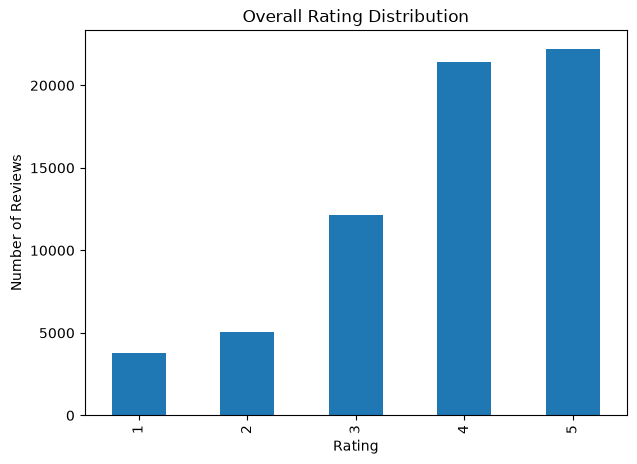

In [5]:
counts = df["overall_rating"].value_counts().sort_index()

plt.figure(figsize=(7,5))
counts.plot(kind="bar")

plt.title("Overall Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

####### Top Job Titles #######

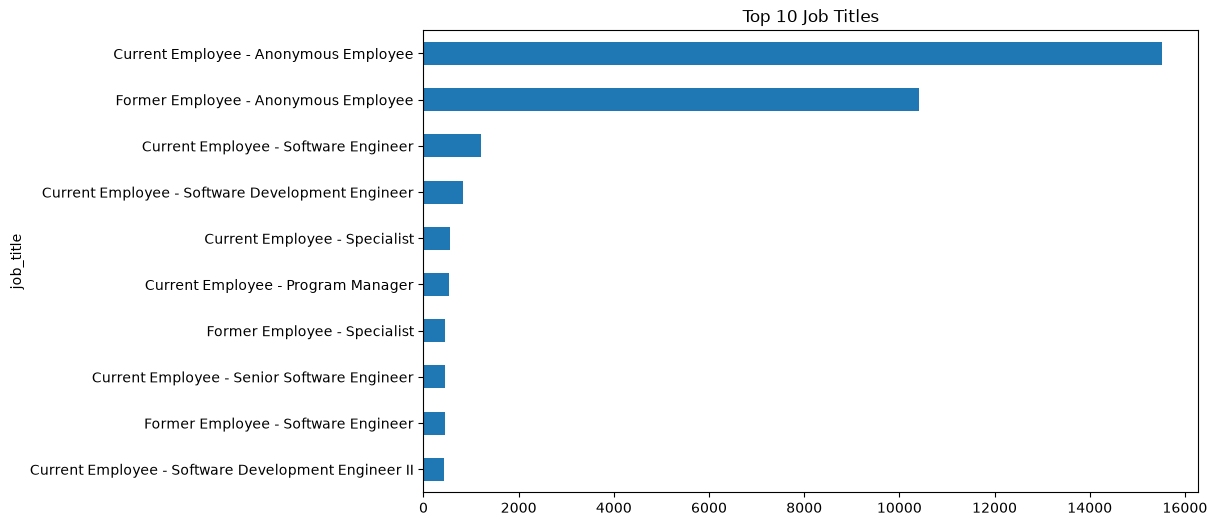

In [6]:
jobs = df["job_title"].value_counts().head(10)

jobs

plt.figure(figsize=(10,6))

jobs.sort_values().plot(kind="barh")

plt.title("Top 10 Job Titles")

plt.show()

In [7]:
####### Review Trend #######

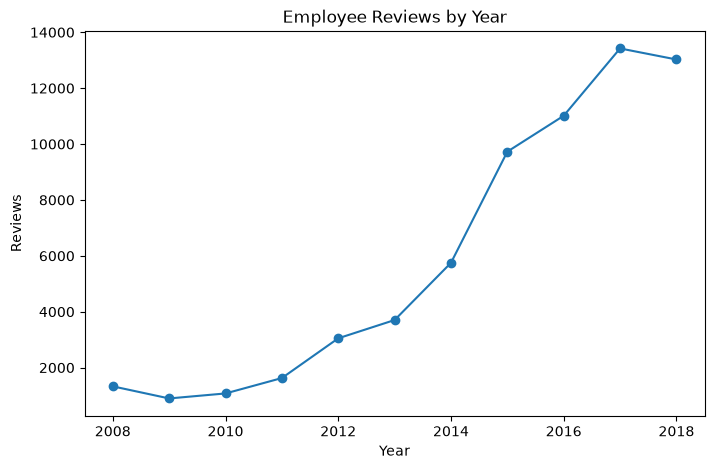

In [8]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

trend = df.groupby(df["date"].dt.year).size()

trend

plt.figure(figsize=(8,5))

trend.plot(marker="o")

plt.title("Employee Reviews by Year")

plt.xlabel("Year")
plt.ylabel("Reviews")

plt.show()

In [9]:
####### Review Length #######

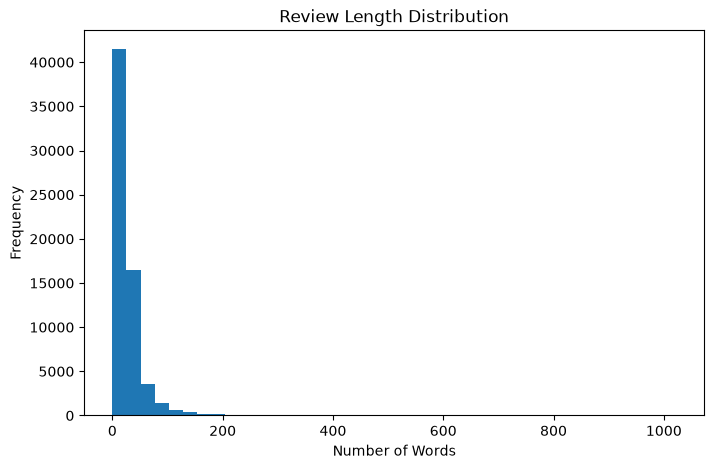

In [10]:
df["review_length"] = (
    df["processed_text"]
    .fillna("")
    .str.split()
    .str.len()
)

df["review_length"].describe()
plt.figure(figsize=(8,5))

plt.hist(df["review_length"], bins=40)

plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [11]:
####### Most Frequent Words #######

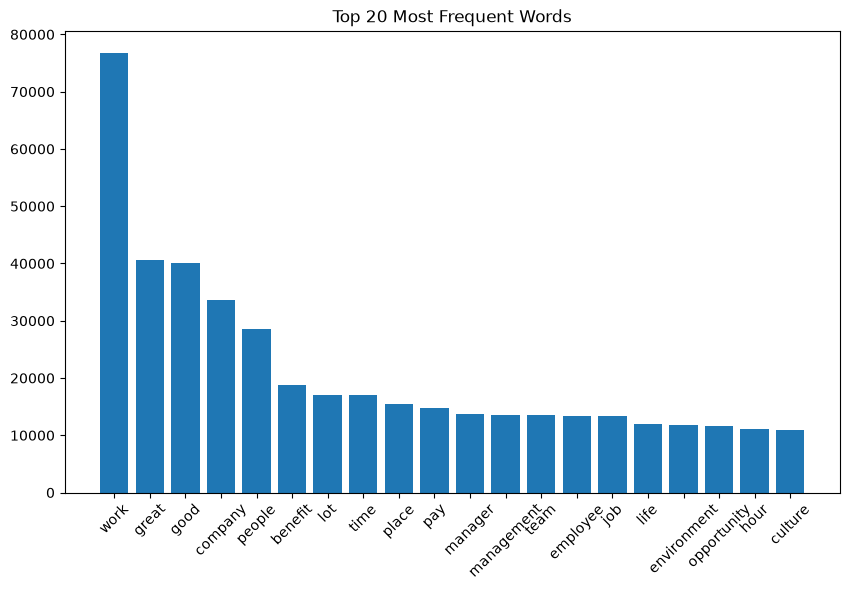

In [12]:
words = " ".join(
    df["processed_text"].dropna()
).split()

counter = Counter(words)

top_words = pd.DataFrame(
    counter.most_common(20),
    columns=["Word", "Frequency"]
)

top_words

plt.figure(figsize=(10,6))

plt.bar(
    top_words["Word"],
    top_words["Frequency"]
)

plt.xticks(rotation=45)

plt.title("Top 20 Most Frequent Words")

plt.show()

In [13]:
####### Correlation #######

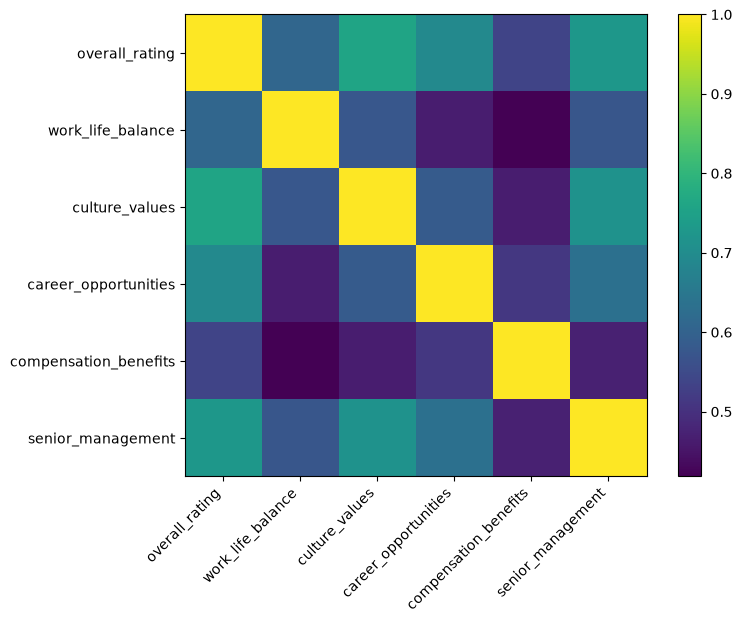

In [14]:
corr = df[rating_cols].corr()

corr

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right",
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns,
)

plt.colorbar()

plt.show()